# Conformalized quantile regression (CQR)

Examples on **real PXR training data**: `morgan_r1_count_1024` fingerprints with the same
**HistGradientBoosting** base as the benchmark `hgb` model (imputer + quantile HGB inside
`ConformalizedQuantileRegressor`).

First import of `load_data` may download the CSV from Hugging Face Hub (then cached).

The first code cell adds `src/` to `sys.path` when you run from the repo root or from `notebooks/`. Alternatively use `PYTHONPATH=src` or `pip install -e .`.

In [5]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Repo `src` on path (works if cwd is project root or `notebooks/`)
for _p in (Path.cwd() / "src", Path.cwd().parent / "src"):
    if _p.is_dir():
        sys.path.insert(0, str(_p.resolve()))
        break

from rdkit import Chem

from baseline import BaselineCVConfig, default_cqr_hgb_regressor, prepare_training_data
from features_data import build_descriptor_matrix
from load_data import train
from sklearn.model_selection import KFold, train_test_split
from uncertainty import cross_validate_conformal_quantile

DESCRIPTOR = "morgan_r1_count_1024"
RANDOM_STATE = 0

## Load data and build the descriptor matrix

Same preparation as `baseline.run_baseline_cv` / `score_data.py`.

In [6]:
cfg = BaselineCVConfig()
mols = list(train["SMILES"].apply(Chem.MolFromSmiles))
y, mols_f, mask = prepare_training_data(train, mols, y_col=cfg.y_col)
X = build_descriptor_matrix(DESCRIPTOR, mols_f).astype(np.float64)
print(f"{DESCRIPTOR}: X shape {X.shape}, y shape {y.shape}")

morgan_r1_count_1024: X shape (4140, 1024), y shape (4140,)


## Hold-out fit: explicit calibration + plots

Fit quantile models on a training subset; calibrate conformal offset on held-out calibration rows;
evaluate coverage and point error on a test split. Base pipeline matches benchmark **hgb** (see
`default_cqr_hgb_regressor`).

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE + 1
)

cqr = default_cqr_hgb_regressor(cfg, alpha=0.1)
cqr.fit(X_fit, y_fit, X_cal, y_cal)

y_pred = cqr.predict(X_test)
interval = cqr.predict_interval(X_test)
lower, upper = interval[:, 0], interval[:, 1]

coverage = np.mean((y_test >= lower) & (y_test <= upper))
rmse = float(np.sqrt(np.mean((y_test - y_pred) ** 2)))
print(f"Hold-out RMSE (median): {rmse:.4f}")
print(
    f"Empirical test coverage: {coverage:.3f}  (nominal ~{1 - cqr.alpha:.0%} marginal)"
)
print(f"Mean interval width: {np.mean(upper - lower):.4f}")
print(f"conformal_offset_: {cqr.conformal_offset_:.4f}")

Hold-out RMSE (median): 0.7439
Empirical test coverage: 0.906  (nominal ~90% marginal)
Mean interval width: 2.6226
conformal_offset_: 0.3139


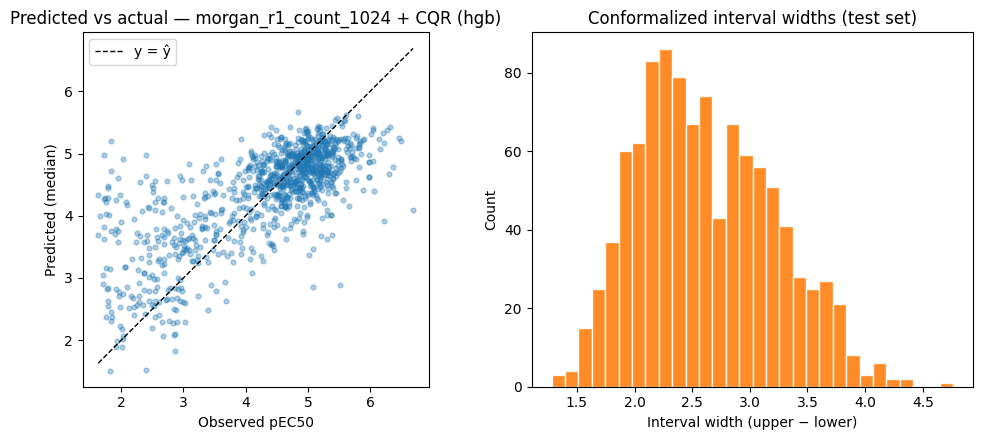

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

ax = axes[0]
lo, hi = float(y_test.min()), float(y_test.max())
ax.scatter(y_test, y_pred, alpha=0.35, s=12, c="C0")
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = ŷ")
ax.set_xlabel("Observed pEC50")
ax.set_ylabel("Predicted (median)")
ax.set_title(f"Predicted vs actual — {DESCRIPTOR} + CQR (hgb)")
ax.legend()
ax.set_aspect("equal", adjustable="box")

ax = axes[1]
widths = upper - lower
ax.hist(widths, bins=30, color="C1", edgecolor="white", alpha=0.9)
ax.set_xlabel("Interval width (upper − lower)")
ax.set_ylabel("Count")
ax.set_title("Conformalized interval widths (test set)")

plt.tight_layout()
plt.show()

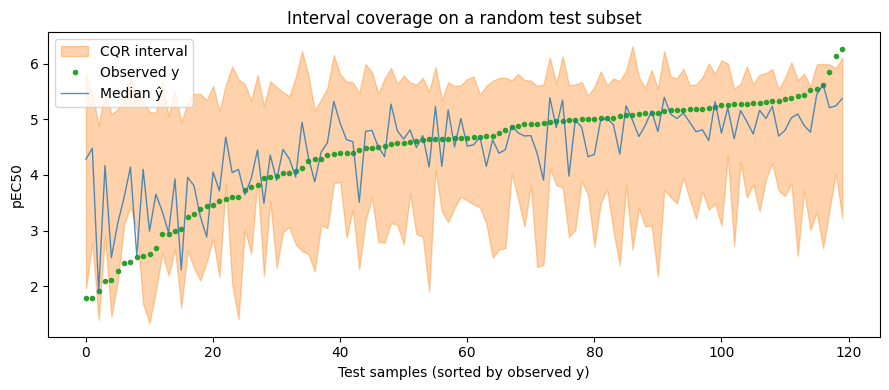

In [9]:
# Sorted view: true y vs prediction band (subset for clarity)
n_show = min(120, len(y_test))
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(y_test), size=n_show, replace=False)
order = np.argsort(y_test[idx])
yt = y_test[idx][order]
lo = lower[idx][order]
hi = upper[idx][order]
yp = y_pred[idx][order]
x = np.arange(n_show)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(x, lo, hi, alpha=0.35, color="C1", label="CQR interval")
ax.plot(x, yt, "o", ms=3, label="Observed y", color="C2")
ax.plot(x, yp, "-", lw=1, alpha=0.8, label="Median ŷ", color="C0")
ax.set_xlabel("Test samples (sorted by observed y)")
ax.set_ylabel("pEC50")
ax.set_title("Interval coverage on a random test subset")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Same outer CV as the benchmark (`BaselineCVConfig` / `KFold`)

`cross_validate_conformal_quantile` uses the same splitter as `run_baseline_cv`, with a nested
fit/calibration split inside each training fold (`run_baseline_cqr_cv` in `baseline.py`).

In [10]:
cv = KFold(
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
    random_state=cfg.cv_random_state,
)
cqr_cv = default_cqr_hgb_regressor(cfg, alpha=0.1)

out = cross_validate_conformal_quantile(
    cqr_cv,
    X,
    y,
    cv,
    calibration_fraction=0.2,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
print("Per-fold RMSE:", np.round(out["test_rmse"], 4))
print("Per-fold R²:  ", np.round(out["test_r2"], 4))
print(
    f"Mean RMSE: {out['test_rmse'].mean():.4f} ± {out['test_rmse'].std():.4f}"
)
print(f"Mean R²:   {out['test_r2'].mean():.4f}")

Per-fold RMSE: [0.733  0.7655 0.7636 0.7781 0.7762]
Per-fold R²:   [0.5483 0.5287 0.5199 0.5572 0.5248]
Mean RMSE: 0.7633 ± 0.0162
Mean R²:   0.5358


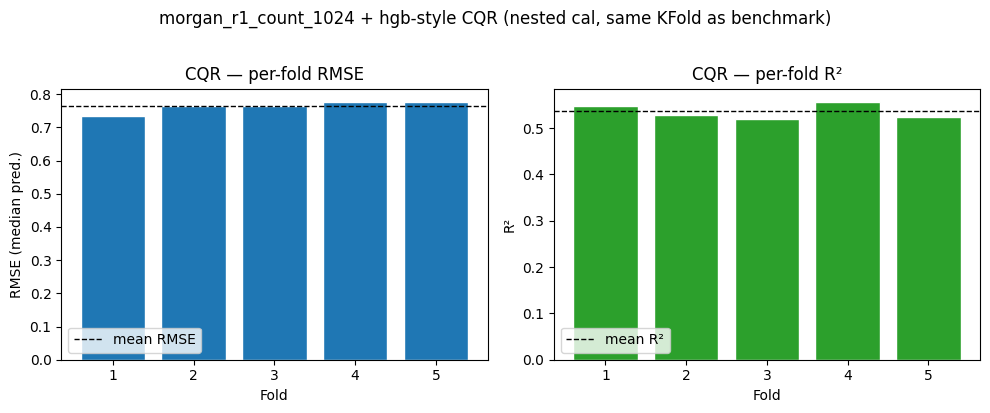

In [11]:
folds = np.arange(1, len(out["test_rmse"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.bar(folds, out["test_rmse"], color="C0", edgecolor="white")
ax.axhline(out["test_rmse"].mean(), color="k", ls="--", lw=1, label="mean RMSE")
ax.set_xlabel("Fold")
ax.set_ylabel("RMSE (median pred.)")
ax.set_title("CQR — per-fold RMSE")
ax.legend()

ax = axes[1]
ax.bar(folds, out["test_r2"], color="C2", edgecolor="white")
ax.axhline(out["test_r2"].mean(), color="k", ls="--", lw=1, label="mean R²")
ax.set_xlabel("Fold")
ax.set_ylabel("R²")
ax.set_title("CQR — per-fold R²")
ax.legend()

plt.suptitle(f"{DESCRIPTOR} + hgb-style CQR (nested cal, same KFold as benchmark)", y=1.02)
plt.tight_layout()
plt.show()

## Full descriptor grid (CLI)

To run CQR across all fingerprints like `score_data.py`:

```bash
cd openadnet && PYTHONPATH=src python src/score_data_cqr.py
```

Writes `outputs/baseline_cqr_cv_results.csv` (and HTML).